In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import mysql.connector
import pandas as pd
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password='999999999',
    database="coffee_sales")

In [4]:
query = "SELECT * FROM coffee_sales.coffeeshop"
df = pd.read_sql(query,conn)
df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15268\1142051719.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
df.shape

(149116, 11)

In [6]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

# EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [9]:
df.dtypes

transaction_id                int64
transaction_date             object
transaction_time    timedelta64[ns]
transaction_qty               int64
store_id                      int64
store_location               object
product_id                    int64
unit_price                  float64
product_category             object
product_type                 object
product_detail               object
dtype: object

In [10]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [11]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'],format='%m/%d/%Y')

In [12]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [13]:
df["transaction_time"] = df['transaction_time'].astype(str).str.split(" ").str[-1] #Removing 0 days from time column

In [14]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [15]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"],format="%H:%M:%S").dt.time
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [16]:
df.dtypes
# IN pandas a pure TIME column is stored as object dtype.
# There is no native tim64 dtype in pandas

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [17]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [19]:
df['revenue'] = df['transaction_qty'] * df["unit_price"]
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [20]:
df['transaction_date'].dt.month_name()

0         January
1         January
2         January
3         January
4         January
           ...   
149111       June
149112       June
149113       June
149114       June
149115       June
Name: transaction_date, Length: 149116, dtype: object

# time intelligence

In [20]:
df['month_name']=df['transaction_date'].dt.month_name()
df['ewwkday']= df['transaction_date'].dt.day_name()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month_name,ewwkday
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,January,Sunday
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,January,Sunday
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,January,Sunday
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday


In [21]:
#EXTRACT HOUR FROM TIME (PEAK HOUR ANALYSIS)
df['hour'] = pd.to_datetime(df['transaction_time'],format='%H:%M:%S').dt.hour
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month_name,ewwkday,hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,January,Sunday,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,January,Sunday,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,January,Sunday,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7


In [22]:
#AVERAGE ORDER VALUE (AOV PREPARATION)
aov = df.groupby('transaction_id')['revenue'].sum().mean()
aov

np.float64(4.686367190643527)

# Data Analysis Business Insights

In [23]:
daily_sales = df.groupby('month_name')['revenue'].sum()

In [24]:
daily_sales

month_name
April       118941.08
February     76145.19
January      81677.74
June        166485.88
March        98834.68
May         156727.76
Name: revenue, dtype: float64

In [25]:
hourly_sales = df.groupby('hour')['revenue'].sum().sort_values(ascending=False)
hourly_sales

hour
10    88673.39
9     85169.53
8     82699.87
7     63526.47
11    46319.14
15    41733.10
14    41304.74
16    41122.75
13    40367.45
12    40192.79
17    40134.31
18    34286.20
19    28446.68
6     21900.27
20     2935.64
Name: revenue, dtype: float64

In [26]:
#store performance comparsion
store_sales = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
store_sales

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64

In [27]:
df['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [28]:
#high volume vs high revenue products
product_analysis = df.groupby('product_category').agg(total_qty=('transaction_qty','sum'),total_revenue=('revenue','sum')).sort_values('total_revenue',ascending=False)
product_analysis

,total_qty,total_revenue
product_category,,
Coffee,89250,269952.45
Tea,69737,196405.95
Bakery,23214,82315.64
Drinking Chocolate,17457,72416.00
Coffee beans,1828,40085.25
Branded,776,13607.00
Loose Tea,1210,11213.60
Flavours,10511,8408.80
Packaged Chocolate,487,4407.64


In [29]:
product_analysis.to_csv('analysis.csv')

In [30]:
df.groupby('hour')['revenue'].sum().index

Index([6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype='int32', name='hour')

In [31]:
df.groupby('hour')['revenue'].sum().values

array([21900.27, 63526.47, 82699.87, 85169.53, 88673.39, 46319.14,
       40192.79, 40367.45, 41304.74, 41733.1 , 41122.75, 40134.31,
       34286.2 , 28446.68,  2935.64])

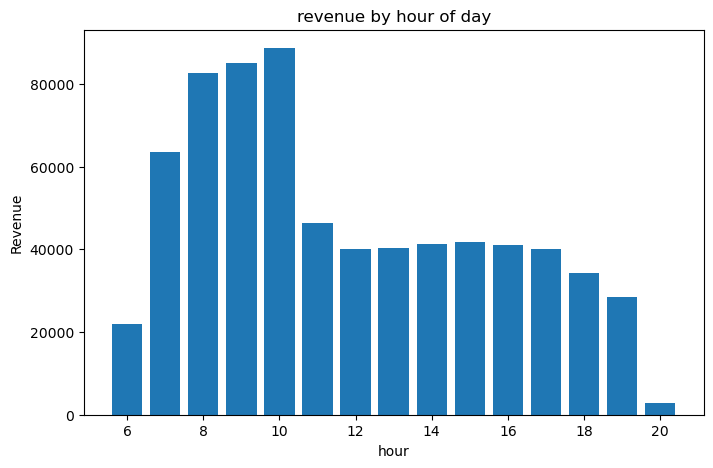

In [32]:
# Revenue by hours
hourly_sales = df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,5))
plt.bar(hourly_sales.index,hourly_sales.values)
plt.title("revenue by hour of day")
plt.xlabel("hour")
plt.ylabel("Revenue")
plt.show()

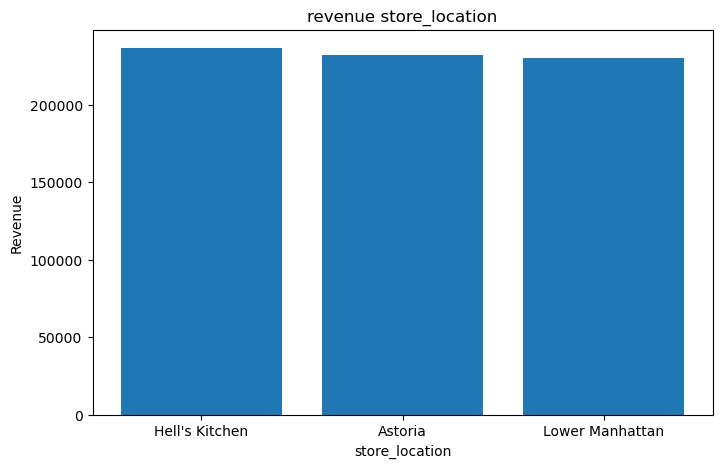

In [35]:
 #Revenue by store
hourly_sales = df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,5))
plt.bar(store_sales.index,store_sales.values)
plt.title("revenue store_location")
plt.xlabel("store_location")
plt.ylabel("Revenue")
plt.show()

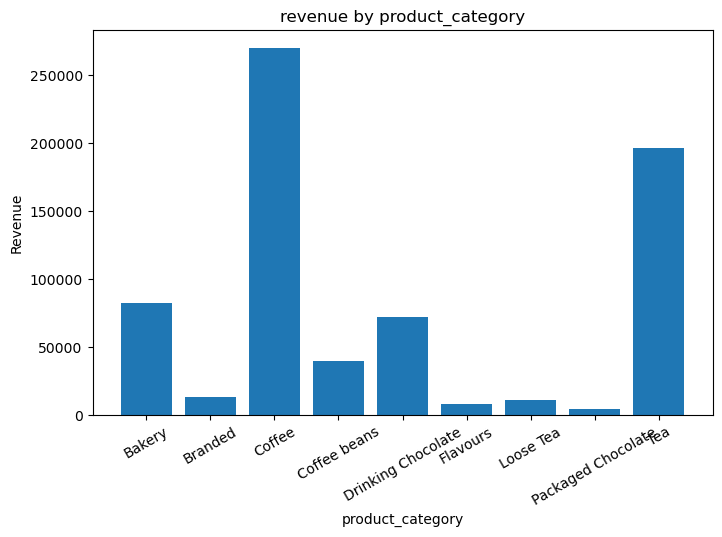

In [37]:
#PRODUCT by product category
category_sales = df.groupby('product_category')['revenue'].sum()
plt.figure(figsize=(8,5))
plt.bar(category_sales.index,category_sales.values)
plt.title("revenue by product_category")
plt.xlabel("product_category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

In [6]:

sns.countplot(df['product_category'],hue = df['store_location'])

NameError: name 'sns' is not defined

# Unstack Function

In [8]:
data = pd.DataFrame({
    'city':['Drlhi','Delhi','mumbai','mumbai'],
     'product':['Laptop','Mobile','Laptop','mobile',],
      'Sales':[250,300,400,500]})
data

,city,product,Sales
0,Drlhi,Laptop,250
1,Delhi,Mobile,300
2,mumbai,Laptop,400
3,mumbai,mobile,500


In [35]:
data.groupby(['city','product'])['Sales'].sum()
#group by create to index in series

city    product
Delhi   Mobile     300
Drlhi   Laptop     250
mumbai  Laptop     400
        mobile     500
Name: Sales, dtype: int64

In [36]:
data.groupby(['city','product'])['Sales'].sum().unstack()

product,Laptop,Mobile,mobile
city,,,
Delhi,NaN,300.0,NaN
Drlhi,250.0,NaN,NaN
mumbai,400.0,NaN,500.0


In [37]:
data.groupby(['city','product'])['Sales'].size().unstack()# to identify count deta hai

product,Laptop,Mobile,mobile
city,,,
Delhi,NaN,1.0,NaN
Drlhi,1.0,NaN,NaN
mumbai,1.0,NaN,1.0


# using unstack to perform Bi variate analysis

In [38]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'revenue', 'month_name', 'ewwkday', 'hour'],
      dtype='object')

In [39]:
df.groupby(['store_location','product_category']).size().unstack()

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,7289,279,20025,502,4300,1490,344,110,16260
Hell's Kitchen,7617,119,20187,720,3763,2370,485,197,15277
Lower Manhattan,7890,349,18204,531,3405,2930,381,180,13912


<Axes: xlabel='store_location'>

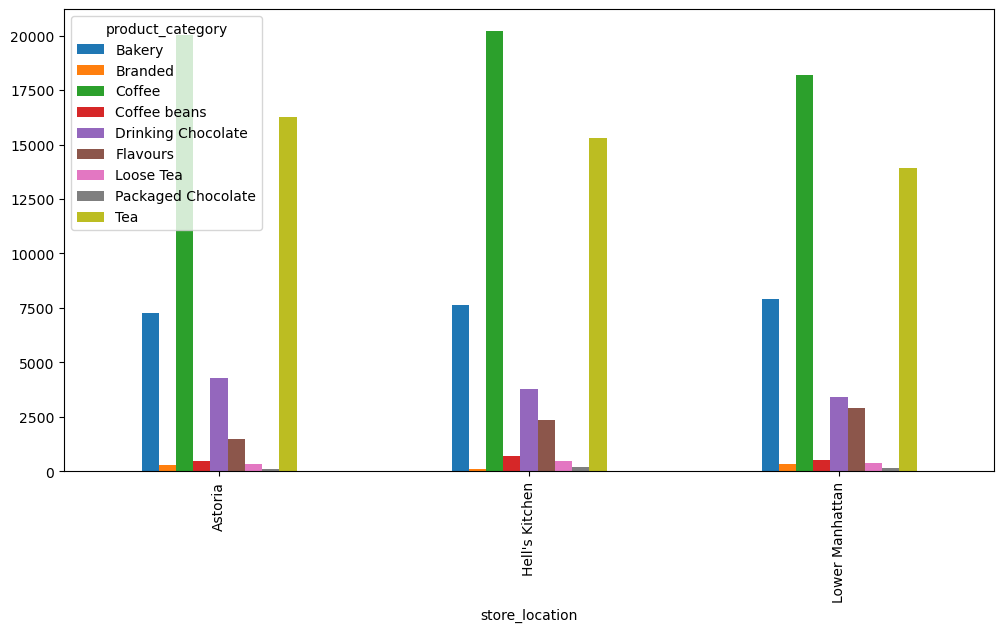

In [40]:
x=df.groupby(['store_location','product_category']).size().unstack()
x.plot(kind = 'bar',figsize = (12,6))

<Axes: xlabel='store_location'>

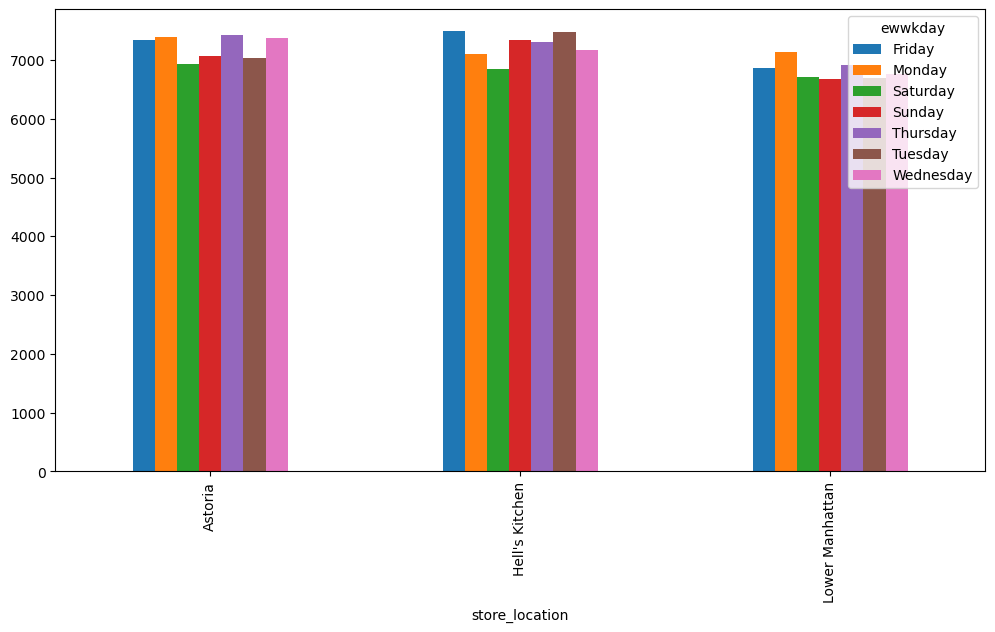

In [41]:
x=df.groupby(['store_location','ewwkday']).size().unstack()
x.plot(kind = 'bar',figsize = (12,6))